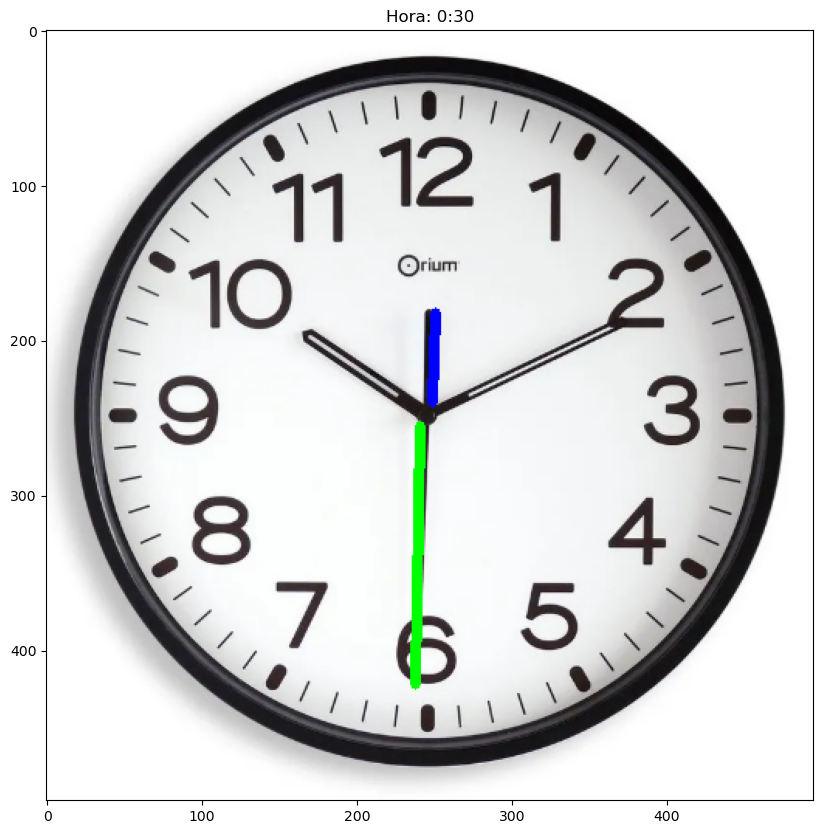

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


imagen_bgr = cv2.imread('reloj6.png')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)


bordes = cv2.Canny(gris, 50, 150)

# Detección de líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)


centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        # LINEAS CENTRO
        if distancia_centro < 100 and 40 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 2:
    # CORTO LARGO
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[0]
    minutero = manecillas[-1]
    
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)

    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    imagen_resultado = imagen_rgb.copy()
    #cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,(horario['puntos'][0], horario['puntos'][1]),(horario['puntos'][2], horario['puntos'][3]), (0, 0, 255), 5)  # horario azul
    cv2.line(imagen_resultado,(minutero['puntos'][0], minutero['puntos'][1]),(minutero['puntos'][2], minutero['puntos'][3]),(0, 255, 0), 5)  # minutero verde

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora: {hora}:{minutos:02d}')
    plt.show()



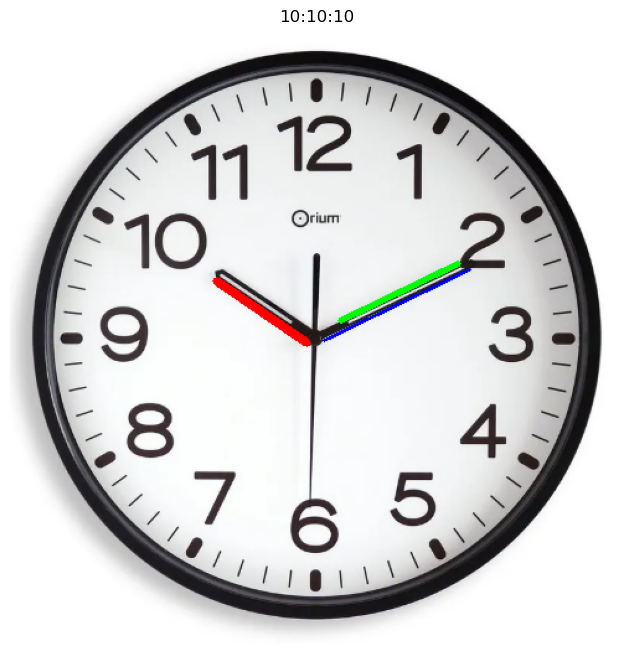

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


img_bgr = cv2.imread('reloj6.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 1)
gray = cv2.equalizeHist(gray)

edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=80, minLineLength=50, maxLineGap=1)

h, w = img_bgr.shape[:2]
cx, cy = w//2, h//2

def calcular_angulo(x1, y1, x2, y2):
    d1 = np.hypot(x1-cx, y1-cy)
    d2 = np.hypot(x2-cx, y2-cy)
    if d1 > d2:
        dx, dy = x1-cx, cy-y1
    else:
        dx, dy = x2-cx, cy-y2
    ang = np.degrees(np.arctan2(dy, dx))
    return (90 - ang) % 360


hands = []
if lines is not None:
    for x1,y1,x2,y2 in lines[:,0]:
        length = np.hypot(x2-x1, y2-y1)
        distc = min(np.hypot(x1-cx, y1-cy), np.hypot(x2-cx, y2-cy))
        if distc < 100 and 40 < length < 300:
            hands.append({
                'pts': (x1,y1,x2,y2),
                'length': length,
                'angle': calcular_angulo(x1,y1,x2,y2)
            })

if len(hands) >= 3:
    # 1) la más corta hora
    hand_hour = min(hands, key=lambda h: h['length'])
    # 2) la más larga segundero
    hand_second = max(hands, key=lambda h: h['length'])
    # 3) minutero
    lengths = np.array([h['length'] for h in hands])
    med = np.median(lengths)
    # descartamos hora y segundo
    middle_candidates = [h for h in hands if h not in (hand_hour, hand_second)]
    hand_minute = min(middle_candidates, key=lambda h: abs(h['length'] - med))

    # --- Calcular hora:min:seg ---
    h_ang = hand_hour['angle']
    m_ang = hand_minute['angle']
    s_ang = hand_second['angle']

    hour = int((h_ang / 30) % 12)
    if (h_ang/30) - hour > 0.5:
        hour = (hour + 1) % 12
    minute = int((m_ang / 6) % 60)
    second = int((s_ang / 6) % 60)

    out = img_rgb.copy()
    cv2.line(out, hand_hour['pts'][:2], hand_hour['pts'][2:],   (255,0,0),  6)  # hora
    cv2.line(out, hand_minute['pts'][:2], hand_minute['pts'][2:], (0,255,0),  4)  # minuto
    cv2.line(out, hand_second['pts'][:2], hand_second['pts'][2:], (0,0,255),  2)  # segundo

    plt.figure(figsize=(8,8))
    plt.imshow(out)
    plt.title(f'{hour:02d}:{minute:02d}:{second:02d}')
    plt.axis('off')
    plt.show()

else:
    print("No se detectaron al menos 3 manecillas válidas.")
